In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import LabelBinarizer, RobustScaler, StandardScaler, MinMaxScaler, QuantileTransformer, PowerTransformer
from sklearn.cluster import DBSCAN, KMeans
from sklearn import metrics
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

In [3]:
# Importer le dataframe préparé
df_complete = pd.read_csv('data_pour_modelisation.csv')

## Feature selection

In [4]:
# Essayer différentes features selection

In [5]:
df_complete.columns

Index(['customer_unique_id', 'number_of_orders', 'mean_price', 'sum_price',
       'mean_score', 'mean_reviews', 'last_order', 'elapsed_time_days'],
      dtype='object')

In [6]:
# Première sélection RFM
selection_1 = ['elapsed_time_days', 'number_of_orders', 'sum_price']
# Sélection avec la satisfaction client
selection_2 = [
    'elapsed_time_days', 'number_of_orders', 'sum_price', 'mean_score'
]
# Séléction avec la satisfaction + reviews
selection_3 = ['number_of_orders', 'mean_score', 'mean_reviews']

In [7]:
# Récupération des features sélectionnées dans des dataframes
df_selection_1 = df_complete[selection_1]
df_selection_2 = df_complete[selection_2]
df_selection_3 = df_complete[selection_3]

In [8]:
# Standardisation des données
scaler = StandardScaler()

In [9]:
df_scaled_1 = scaler.fit_transform(df_selection_1)
df_scaled_2 = scaler.fit_transform(df_selection_2)
df_scaled_3 = scaler.fit_transform(df_selection_3)

In [10]:
# Modèle de Kmeans détermination de K avec la première sélection de feature
model = KMeans(random_state=5)
visualizer = KElbowVisualizer(model, k=(2, 10))

KElbowVisualizer(ax=<AxesSubplot:>,
                 estimator=KMeans(n_clusters=9, random_state=5), k=(2, 10))

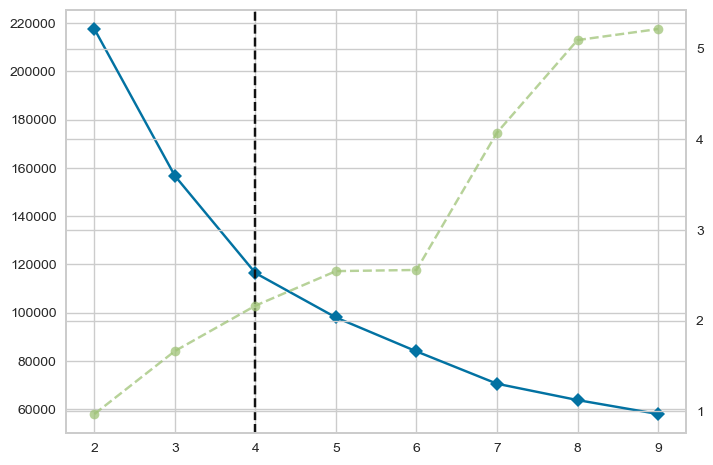

In [11]:
visualizer.fit(df_scaled_1)

In [12]:
kmeans = KMeans(n_clusters=4, random_state=5).fit(df_scaled_1)
metrics.silhouette_score(df_scaled_1, kmeans.labels_, metric="euclidean")

0.43598618855680726

In [13]:
# Modèle de Kmeans détermination de K avec la seconde sélection de feature
model = KMeans(random_state=5)
visualizer = KElbowVisualizer(model, k=(2, 10))

KElbowVisualizer(ax=<AxesSubplot:>,
                 estimator=KMeans(n_clusters=9, random_state=5), k=(2, 10))

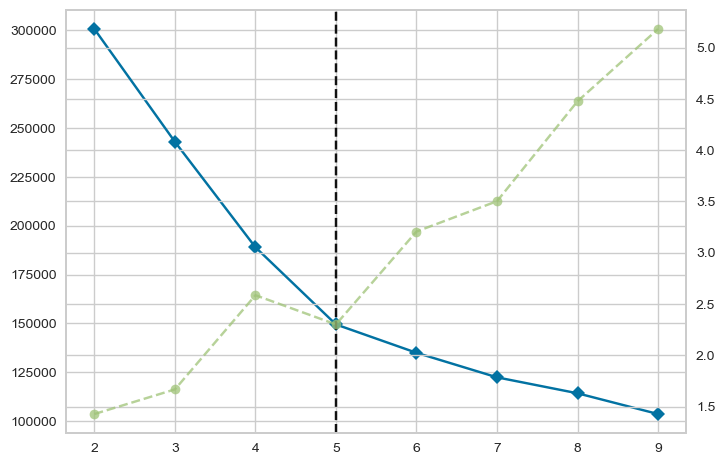

In [14]:
visualizer.fit(df_scaled_2)

In [15]:
kmeans = KMeans(n_clusters=5, random_state=5).fit(df_scaled_2)
metrics.silhouette_score(df_scaled_2, kmeans.labels_, metric="euclidean")

0.3762466316706913

In [16]:
# Modèle de Kmeans détermination de K avec la troisième sélection de feature
model = KMeans(random_state=5)
visualizer = KElbowVisualizer(model, k=(2, 10))

KElbowVisualizer(ax=<AxesSubplot:>,
                 estimator=KMeans(n_clusters=9, random_state=5), k=(2, 10))

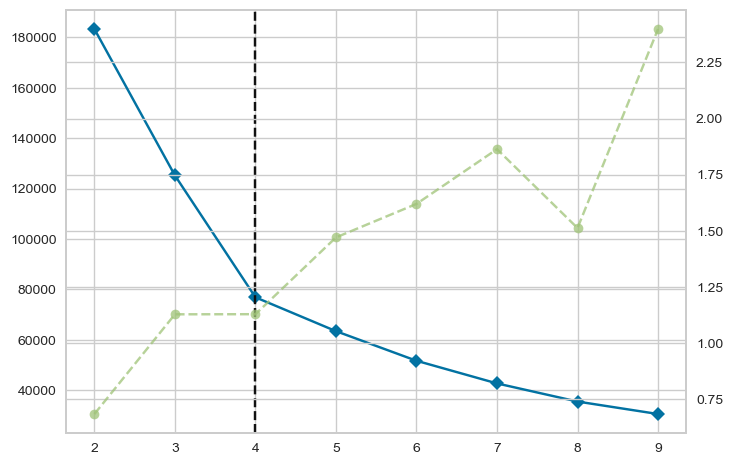

In [17]:
visualizer.fit(df_scaled_3)

In [18]:
kmeans = KMeans(n_clusters=4, random_state=4).fit(df_scaled_3)
metrics.silhouette_score(df_scaled_3, kmeans.labels_, metric="euclidean")

0.6616791037524954

In [19]:
visualizer = SilhouetteVisualizer(kmeans)

SilhouetteVisualizer(ax=<AxesSubplot:>,
                     estimator=KMeans(n_clusters=4, random_state=4))

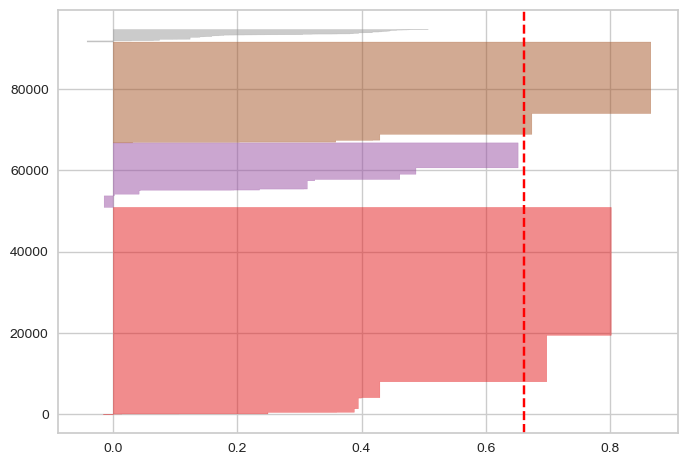

In [20]:
visualizer.fit(df_scaled_3)

In [21]:
# Autre essai : utilisation d'un score pour chaque feature
# Transformation des différentes features en scores de 1 à 5

In [22]:
df_selection_1['Score_R'] = (df_selection_1['elapsed_time_days'] -
                             df_selection_1['elapsed_time_days'].min()) / (
                                 df_selection_1['elapsed_time_days'].max() -
                                 df_selection_1['elapsed_time_days'].min())
df_selection_1['Score_F'] = (df_selection_1['number_of_orders'] -
                             df_selection_1['number_of_orders'].min()) / (
                                 df_selection_1['number_of_orders'].max() -
                                 df_selection_1['number_of_orders'].min())
df_selection_1['Score_M'] = (
    df_selection_1['sum_price'] - df_selection_1['sum_price'].min()) / (
        df_selection_1['sum_price'].max() - df_selection_1['sum_price'].min())

C:\Users\LN6428\AppData\Local\Temp\ipykernel_5612\1270493851.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selection_1['Score_R'] = (df_selection_1['elapsed_time_days']-df_selection_1['elapsed_time_days'].min())/(df_selection_1['elapsed_time_days'].max()-df_selection_1['elapsed_time_days'].min())
C:\Users\LN6428\AppData\Local\Temp\ipykernel_5612\1270493851.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selection_1['Score_F'] = (df_selection_1['number_of_orders']-df_selection_1['number_of_or

In [23]:
df_selection_1.describe()

,elapsed_time_days,number_of_orders,sum_price,Score_R,Score_F,Score_M
count,94721.000000,94721.000000,94721.000000,94721.000000,94721.000000,94721.000000
mean,1800.343989,1.186347,142.811254,0.333805,0.008102,0.010563
std,153.171225,0.646716,217.714921,0.210111,0.028118,0.016200
min,1557.000000,1.000000,0.850000,0.000000,0.000000,0.000000
25%,1676.000000,1.000000,47.900000,0.163237,0.000000,0.003501
50%,1781.000000,1.000000,89.900000,0.307270,0.000000,0.006626
75%,1910.000000,1.000000,155.960000,0.484225,0.000000,0.011542
max,2286.000000,24.000000,13440.000000,1.000000,1.000000,1.000000


In [24]:
df_selection_1['Log_M'] = np.log10(df_selection_1['sum_price'])

C:\Users\LN6428\AppData\Local\Temp\ipykernel_5612\2529844236.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selection_1['Log_M'] = np.log10(df_selection_1['sum_price'])


In [25]:
df_selection_1['Score_M2'] = (
    df_selection_1['Log_M'] - df_selection_1['Log_M'].min()) / (
        df_selection_1['Log_M'].max() - df_selection_1['Log_M'].min())

In [26]:
from sklearn.preprocessing import QuantileTransformer

In [27]:
transf = QuantileTransformer(n_quantiles=5)

In [28]:
df_selection_1['Score_F2'] = transf.fit_transform(
    pd.array(df_selection_1['number_of_orders']).reshape(-1, 1))

In [29]:
df_selection_1.describe()

,elapsed_time_days,number_of_orders,sum_price,Score_R,Score_F,Score_M,Log_M,Score_M2,Score_F2
count,94721.000000,94721.000000,94721.000000,94721.000000,94721.000000,94721.000000,94721.000000,94721.000000,94721.000000
mean,1800.343989,1.186347,142.811254,0.333805,0.008102,0.010563,1.942630,0.479452,0.095489
std,153.171225,0.646716,217.714921,0.210111,0.028118,0.016200,0.408815,0.097361,0.253125
min,1557.000000,1.000000,0.850000,0.000000,0.000000,0.000000,-0.070581,0.000000,0.000000
25%,1676.000000,1.000000,47.900000,0.163237,0.000000,0.003501,1.680336,0.416986,0.000000
50%,1781.000000,1.000000,89.900000,0.307270,0.000000,0.006626,1.953760,0.482103,0.000000
75%,1910.000000,1.000000,155.960000,0.484225,0.000000,0.011542,2.193013,0.539082,0.000000
max,2286.000000,24.000000,13440.000000,1.000000,1.000000,1.000000,4.128399,1.000000,1.000000


In [30]:
features = ['Score_R', 'Score_F2', 'Score_M2']
df_test = df_selection_1[features]

In [31]:
df_test.describe()

,Score_R,Score_F2,Score_M2
count,94721.000000,94721.000000,94721.000000
mean,0.333805,0.095489,0.479452
std,0.210111,0.253125,0.097361
min,0.000000,0.000000,0.000000
25%,0.163237,0.000000,0.416986
50%,0.307270,0.000000,0.482103
75%,0.484225,0.000000,0.539082
max,1.000000,1.000000,1.000000


In [32]:
model = KMeans(random_state=5)
visualizer = KElbowVisualizer(model, k=(2, 10))

KElbowVisualizer(ax=<AxesSubplot:>,
                 estimator=KMeans(n_clusters=9, random_state=5), k=(2, 10))

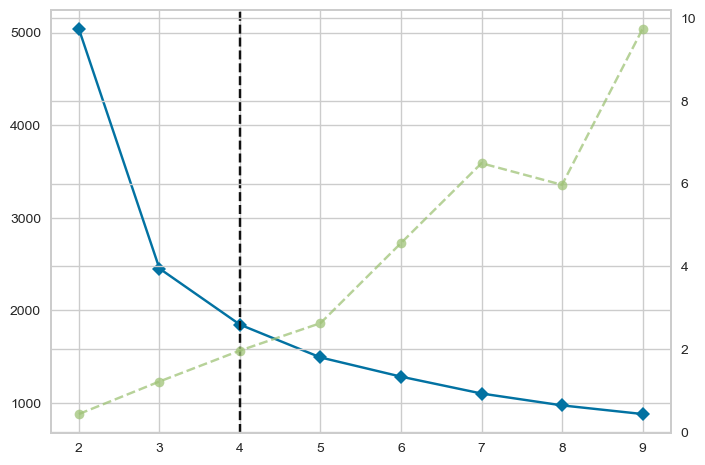

In [33]:
visualizer.fit(df_test)

In [34]:
kmeans = KMeans(n_clusters=4, random_state=4).fit(df_test)
metrics.silhouette_score(df_test, kmeans.labels_, metric="euclidean")

0.43018285237136733

In [35]:
visualizer = SilhouetteVisualizer(kmeans)

C:\Users\LN6428\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


SilhouetteVisualizer(ax=<AxesSubplot:>,
                     estimator=KMeans(n_clusters=4, random_state=4))

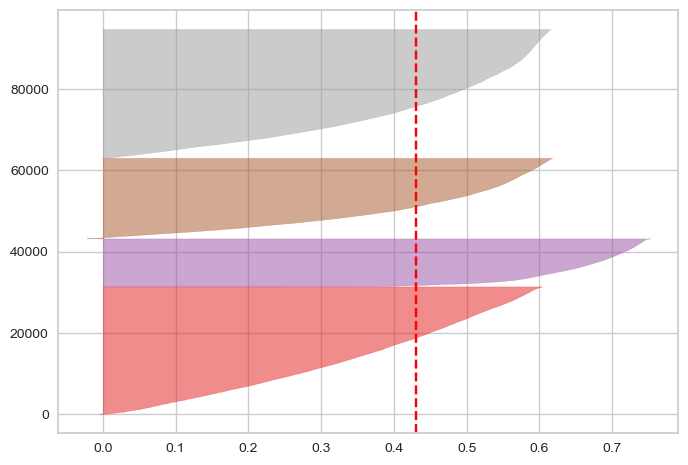

In [36]:
visualizer.fit(df_test)

In [37]:
from mpl_toolkits.mplot3d import Axes3D

In [38]:
pd.array(df_test)[:, 0].to_numpy()

array(['[0.15912209 0.         0.52017158]',
       '[0.16323731 0.         0.32080238]',
       '[0.74348422 0.         0.45473663]', ...,
       '[0.78600823 0.         0.48210294]',
       '[0.17009602 0.         0.50757059]',
       '[0.67078189 0.         0.43495791]'], dtype=object)

In [39]:
df_test.dtypes

Score_R     float64
Score_F2    float64
Score_M2    float64
dtype: object

In [40]:
df_test.loc[:, 'Score_R']

0        0.159122
1        0.163237
2        0.743484
3        0.447188
4        0.401920
           ...   
94716    0.620027
94717    0.366255
94718    0.786008
94719    0.170096
94720    0.670782
Name: Score_R, Length: 94721, dtype: float64

In [41]:
sns.set_theme()

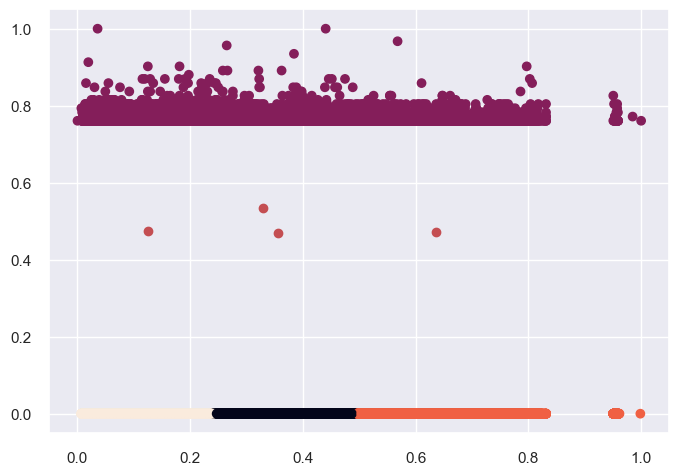

In [42]:
plt.scatter(df_test.loc[:, 'Score_R'],
            df_test.loc[:, 'Score_F2'],
            c=kmeans.predict(df_test))
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 2],
            c='r')

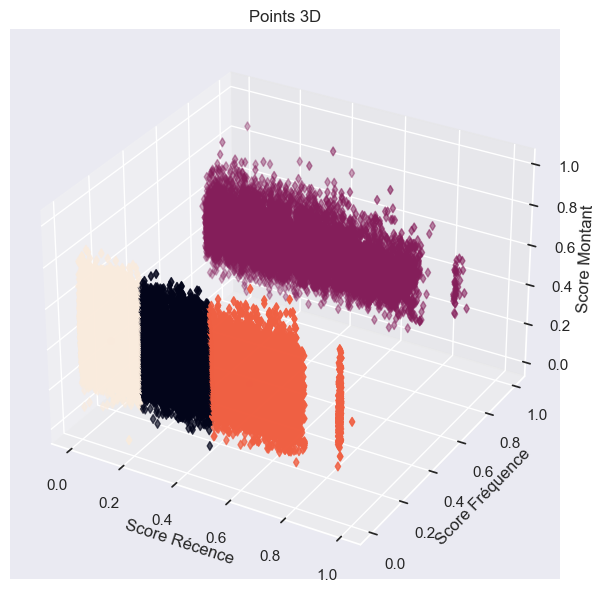

In [43]:
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)  # Affichage en 3D
fig.add_axes(ax)
ax.scatter(df_test.loc[:, 'Score_R'],
           df_test.loc[:, 'Score_F2'],
           df_test.loc[:, 'Score_M2'],
           label='Courbe',
           marker='d',
           c=kmeans.predict(df_test))  # Tracé des points 3D
ax.scatter(kmeans.cluster_centers_[:, 0],
           kmeans.cluster_centers_[:, 1],
           kmeans.cluster_centers_[:, 2],
           c='r')
plt.title("Points 3D")
ax.set_xlabel('Score Récence')
ax.set_ylabel('Score Fréquence')
ax.set_zlabel("Score Montant")
plt.show()

In [44]:
df_selection_2['Score_R'] = (df_selection_2['elapsed_time_days'] -
                             df_selection_2['elapsed_time_days'].min()) / (
                                 df_selection_2['elapsed_time_days'].max() -
                                 df_selection_2['elapsed_time_days'].min())
df_selection_2['Score_F'] = (df_selection_2['number_of_orders'] -
                             df_selection_2['number_of_orders'].min()) / (
                                 df_selection_2['number_of_orders'].max() -
                                 df_selection_2['number_of_orders'].min())
df_selection_2['Score_M'] = (
    df_selection_2['sum_price'] - df_selection_2['sum_price'].min()) / (
        df_selection_2['sum_price'].max() - df_selection_2['sum_price'].min())

C:\Users\LN6428\AppData\Local\Temp\ipykernel_5612\2016973960.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selection_2['Score_R'] = (df_selection_2['elapsed_time_days']-df_selection_2['elapsed_time_days'].min())/(df_selection_2['elapsed_time_days'].max()-df_selection_2['elapsed_time_days'].min())
C:\Users\LN6428\AppData\Local\Temp\ipykernel_5612\2016973960.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selection_2['Score_F'] = (df_selection_2['number_of_orders']-df_selection_2['number_of_or

In [45]:
df_selection_2

,elapsed_time_days,number_of_orders,sum_price,mean_score,Score_R,Score_F,Score_M
0,1673,1,129.90,5.0,0.159122,0.000000,0.009603
1,1676,1,18.90,4.0,0.163237,0.000000,0.001343
2,2099,1,69.00,3.0,0.743484,0.000000,0.005071
3,1883,1,25.99,4.0,0.447188,0.000000,0.001871
4,1850,1,180.00,5.0,0.401920,0.000000,0.013330
...,...,...,...,...,...,...,...
94716,2009,2,1570.00,5.0,0.620027,0.043478,0.116760
94717,1824,1,64.89,4.0,0.366255,0.000000,0.004765
94718,2130,1,89.90,5.0,0.786008,0.000000,0.006626
94719,1681,1,115.00,5.0,0.170096,0.000000,0.008494


In [46]:
df_selection_2['Score_Review'] = (df_selection_2['mean_score'] / 5)

In [47]:
df_selection_2

,elapsed_time_days,number_of_orders,sum_price,mean_score,Score_R,Score_F,Score_M,Score_Review
0,1673,1,129.90,5.0,0.159122,0.000000,0.009603,1.0
1,1676,1,18.90,4.0,0.163237,0.000000,0.001343,0.8
2,2099,1,69.00,3.0,0.743484,0.000000,0.005071,0.6
3,1883,1,25.99,4.0,0.447188,0.000000,0.001871,0.8
4,1850,1,180.00,5.0,0.401920,0.000000,0.013330,1.0
...,...,...,...,...,...,...,...,...
94716,2009,2,1570.00,5.0,0.620027,0.043478,0.116760,1.0
94717,1824,1,64.89,4.0,0.366255,0.000000,0.004765,0.8
94718,2130,1,89.90,5.0,0.786008,0.000000,0.006626,1.0
94719,1681,1,115.00,5.0,0.170096,0.000000,0.008494,1.0


In [48]:
features = ['Score_R', 'Score_F', 'Score_M', 'Score_Review']
selection = df_selection_2[features]

In [49]:
model = KMeans(random_state=5)
visualizer = KElbowVisualizer(model, k=(2, 10))

KElbowVisualizer(ax=<AxesSubplot:>,
                 estimator=KMeans(n_clusters=9, random_state=5), k=(2, 10))

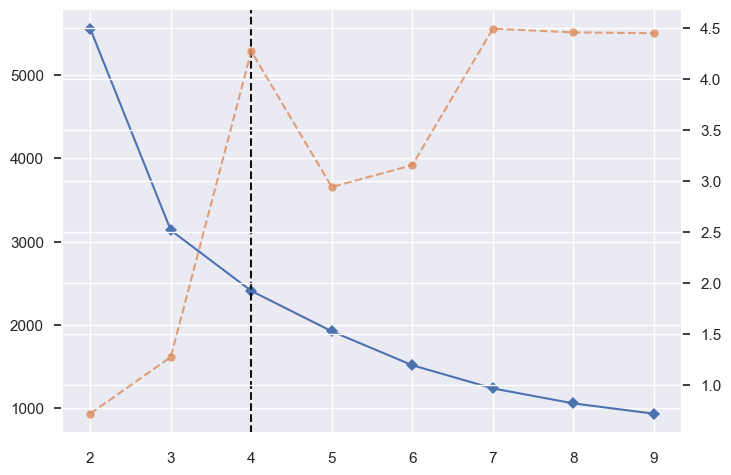

In [50]:
visualizer.fit(selection)

In [51]:
kmeans = KMeans(n_clusters=4, random_state=5).fit(selection)
metrics.silhouette_score(selection, kmeans.labels_, metric="euclidean")

0.45770127667250277

In [52]:
visualizer = SilhouetteVisualizer(kmeans)

C:\Users\LN6428\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


SilhouetteVisualizer(ax=<AxesSubplot:>,
                     estimator=KMeans(n_clusters=4, random_state=5))

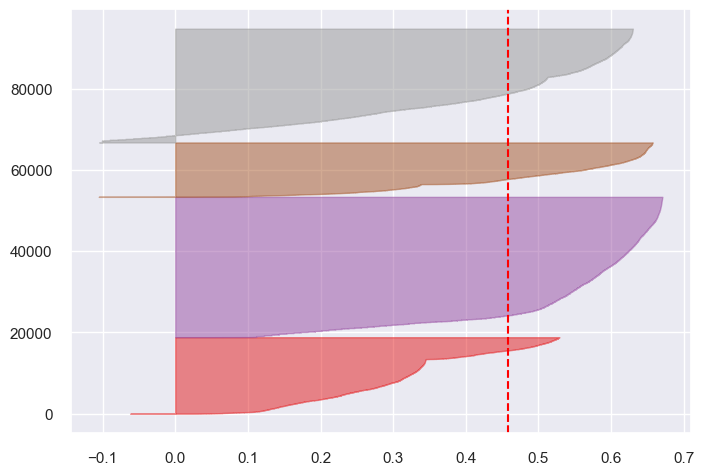

In [54]:
visualizer.fit(selection)

In [55]:
selection

,Score_R,Score_F,Score_M,Score_Review
0,0.159122,0.000000,0.009603,1.0
1,0.163237,0.000000,0.001343,0.8
2,0.743484,0.000000,0.005071,0.6
3,0.447188,0.000000,0.001871,0.8
4,0.401920,0.000000,0.013330,1.0
...,...,...,...,...
94716,0.620027,0.043478,0.116760,1.0
94717,0.366255,0.000000,0.004765,0.8
94718,0.786008,0.000000,0.006626,1.0
94719,0.170096,0.000000,0.008494,1.0


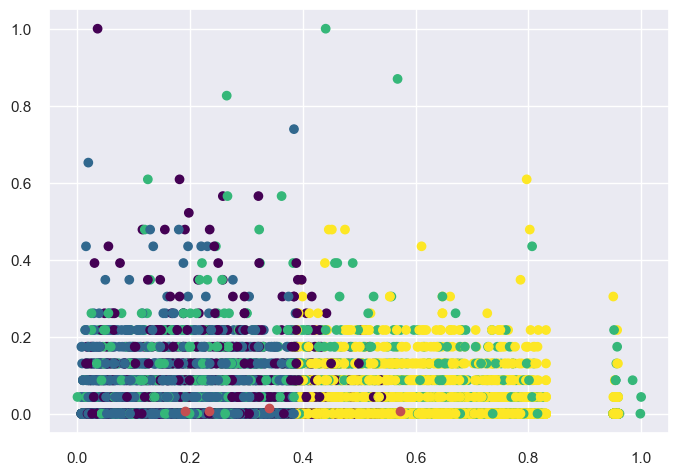

In [56]:
plt.scatter(selection.iloc[:, 0],
            selection.iloc[:, 1],
            c=kmeans.predict(selection),
            cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            c='r')

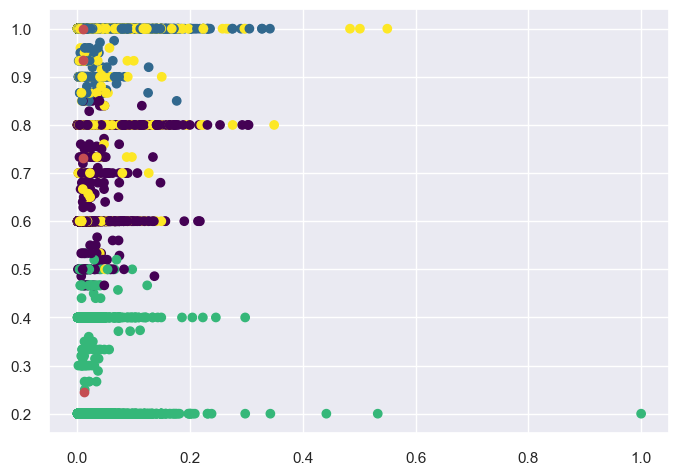

In [57]:
plt.scatter(selection.iloc[:, 2],
            selection.iloc[:, 3],
            c=kmeans.predict(selection),
            cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 2],
            kmeans.cluster_centers_[:, 3],
            c='r')

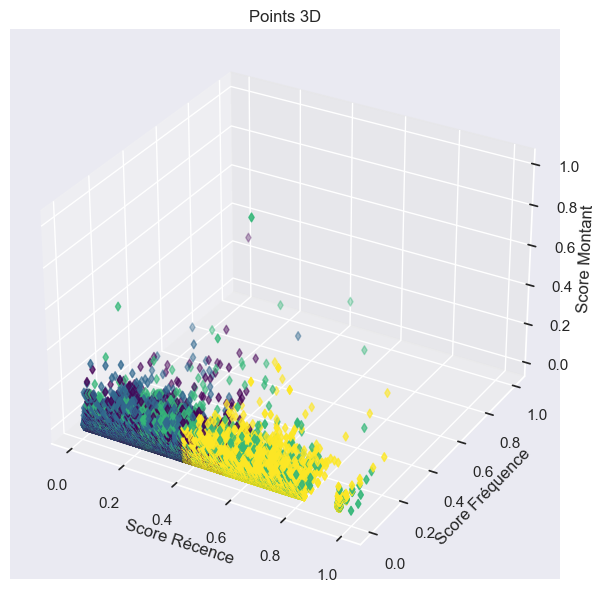

In [58]:
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)  # Affichage en 3D
fig.add_axes(ax)
ax.scatter(selection.loc[:, 'Score_R'],
           selection.loc[:, 'Score_F'],
           selection.loc[:, 'Score_M'],
           label='Courbe',
           marker='d',
           c=kmeans.predict(selection),
           cmap='viridis')  # Tracé des points 3D
ax.scatter(kmeans.cluster_centers_[:, 0],
           kmeans.cluster_centers_[:, 1],
           kmeans.cluster_centers_[:, 2],
           c='r')
plt.title("Points 3D")
ax.set_xlabel('Score Récence')
ax.set_ylabel('Score Fréquence')
ax.set_zlabel("Score Montant")
plt.show()

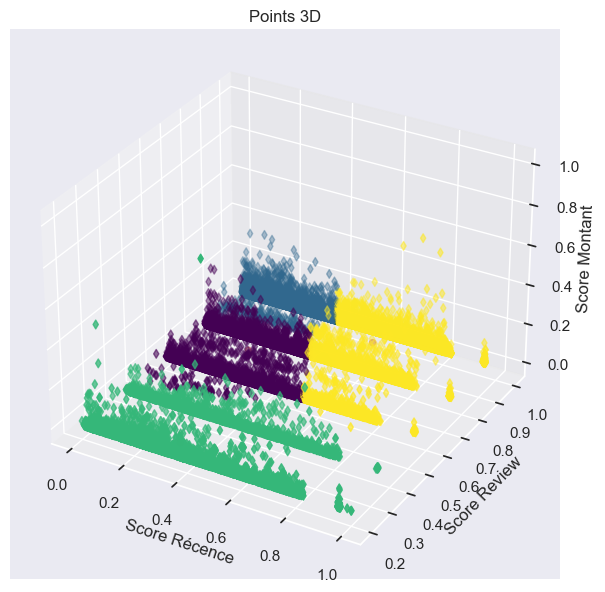

In [59]:
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)  # Affichage en 3D
fig.add_axes(ax)
ax.scatter(selection.loc[:, 'Score_R'],
           selection.loc[:, 'Score_Review'],
           selection.loc[:, 'Score_M'],
           label='Courbe',
           marker='d',
           c=kmeans.predict(selection),
           cmap='viridis')  # Tracé des points 3D
ax.scatter(kmeans.cluster_centers_[:, 0],
           kmeans.cluster_centers_[:, 3],
           kmeans.cluster_centers_[:, 2],
           c='r')
plt.title("Points 3D")
ax.set_xlabel('Score Récence')
ax.set_ylabel('Score Review')
ax.set_zlabel("Score Montant")
plt.show()

In [60]:
selection

,Score_R,Score_F,Score_M,Score_Review
0,0.159122,0.000000,0.009603,1.0
1,0.163237,0.000000,0.001343,0.8
2,0.743484,0.000000,0.005071,0.6
3,0.447188,0.000000,0.001871,0.8
4,0.401920,0.000000,0.013330,1.0
...,...,...,...,...
94716,0.620027,0.043478,0.116760,1.0
94717,0.366255,0.000000,0.004765,0.8
94718,0.786008,0.000000,0.006626,1.0
94719,0.170096,0.000000,0.008494,1.0


In [61]:
# Modèle choisi : K-means K=4
# Features : selection1 RFM classique

## Analyse des segments

In [62]:
model = KMeans(n_clusters=4, random_state=5).fit(df_scaled_1)

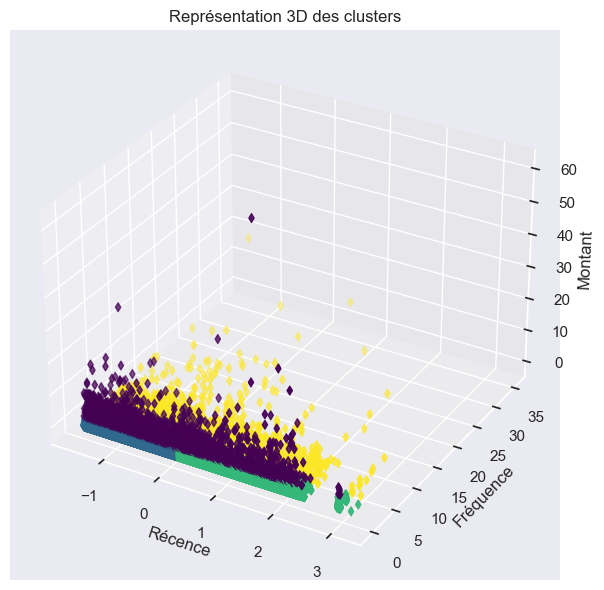

In [63]:
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)  # Affichage en 3D
fig.add_axes(ax)
ax.scatter(df_scaled_1[:, 0],
           df_scaled_1[:, 1],
           df_scaled_1[:, 2],
           label='Courbe',
           marker='d',
           c=model.predict(df_scaled_1),
           cmap='viridis')  # Tracé des points 3D
ax.scatter(model.cluster_centers_[:, 0],
           model.cluster_centers_[:, 1],
           model.cluster_centers_[:, 2],
           c='r')
plt.title("Représentation 3D des clusters")
ax.set_xlabel('Récence')
ax.set_ylabel('Fréquence')
ax.set_zlabel('Montant')
plt.show()

Text(0, 0.5, 'Fréquence')

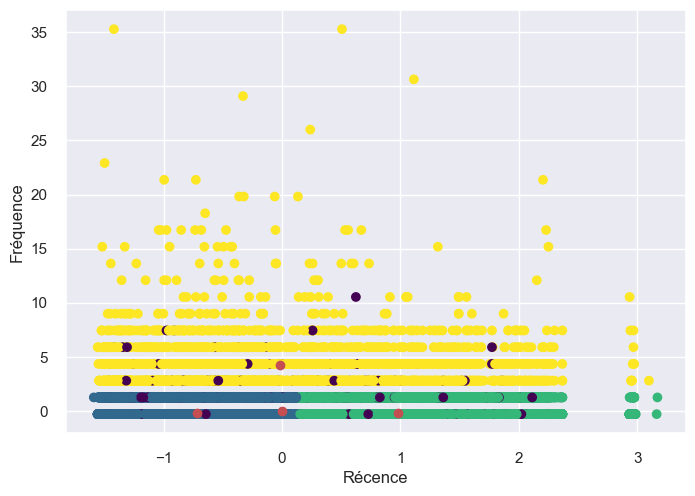

In [64]:
plt.scatter(df_scaled_1[:, 0],
            df_scaled_1[:, 1],
            c=model.predict(df_scaled_1),
            cmap='viridis')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c='r')
plt.xlabel('Récence')
plt.ylabel('Fréquence')

Text(0, 0.5, 'Montant')

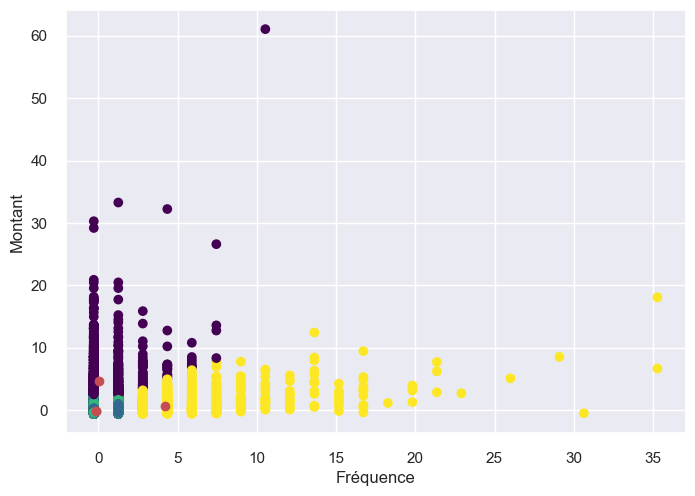

In [65]:
plt.scatter(df_scaled_1[:, 1],
            df_scaled_1[:, 2],
            c=model.predict(df_scaled_1),
            cmap='viridis')
plt.scatter(model.cluster_centers_[:, 1], model.cluster_centers_[:, 2], c='r')
plt.xlabel('Fréquence')
plt.ylabel('Montant')

Text(0, 0.5, 'Montant')

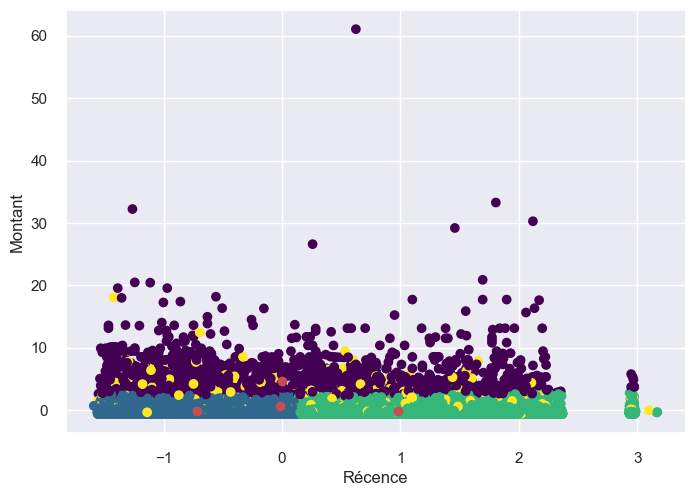

In [66]:
plt.scatter(df_scaled_1[:, 0],
            df_scaled_1[:, 2],
            c=model.predict(df_scaled_1),
            cmap='viridis')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 2], c='r')
plt.xlabel('Récence')
plt.ylabel('Montant')

### Description des clusters :
Jaune : Fréquence élevée
Violet : Montant élevé
Bleu : Dernière commande récente
Vert : Dernière commande il y a longtemps

In [67]:
df_selection_1['clusters'] = model.predict(df_scaled_1)

In [68]:
df_selection_1.groupby('clusters').describe()

elapsed_time_days                                                   \
                     count         mean         std     min     25%     50%   
clusters                                                                      
0                   2111.0  1799.918048  152.868507  1563.0  1673.0  1781.0   
1                  51695.0  1690.321346   72.684110  1557.0  1627.0  1692.0   
2                  37917.0  1950.593349   96.256657  1821.0  1863.0  1938.0   
3                   2998.0  1797.513676  149.285971  1562.0  1678.0  1777.0   

                         number_of_orders            ...  Score_M2            \
             75%     max            count      mean  ...       75%       max   
clusters                                             ...                       
0         1912.0  2256.0           2111.0  1.207011  ...  0.760087  1.000000   
1         1752.0  1820.0          51695.0  1.095715  ...  0.533664  0.689847   
2         2025.0  2286.0          37917.0  1.093494  ...  0.531474  0.700123   
3         1897.0  2275.0           2998.0  3.908939  ...  0.625485  0.876699   

         Score_F2                                                              \
            count      mean       std       min       25%       50%       75%   
clusters                                                                        
0          2111.0  0.113453  0.272007  0.000000  0.000000  0.000000  0.000000   
1         51695.0  0.072827  0.223850  0.000000  0.000000  0.000000  0.000000   
2         37917.0  0.071136  0.221510  0.000000  0.000000  0.000000  0.000000   
3          2998.0  0.781619  0.017984  0.771739  0.771739  0.771739  0.782609   

                    
               max  
clusters            
0         0.826087  
1         0.760870  
2         0.760870  
3         1.000000  

[4 rows x 72 columns]

In [69]:
liste = ['elapsed_time_days', 'number_of_orders', 'sum_price', 'clusters']

In [70]:
df_selection_1 = df_selection_1[liste]

In [71]:
features = ['elapsed_time_days', 'number_of_orders', 'sum_price']

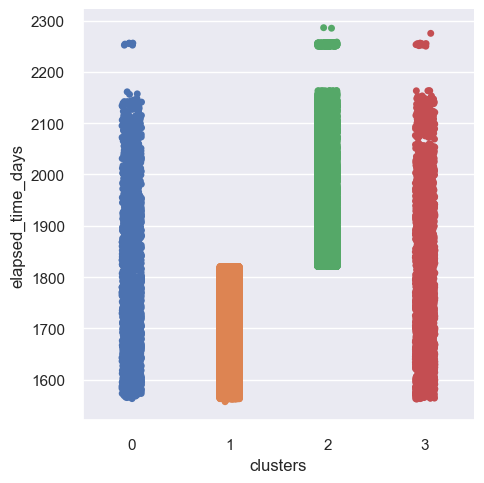

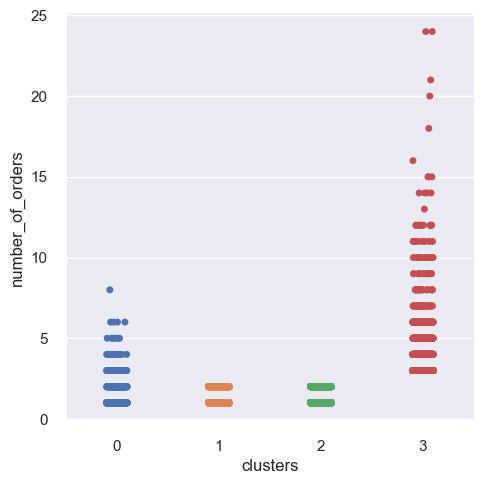

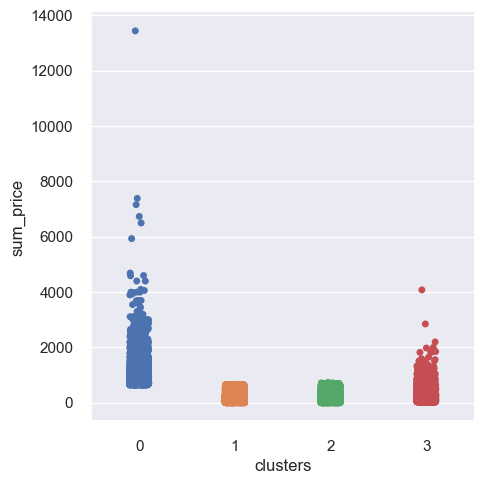

In [72]:
for i in features:
    sns.catplot(x='clusters', y=i, data=df_selection_1)

## Stabilité des clusters
Faire varier les autres hyperparamètres, vérifier l'obtention des mêmes clusters avec plusieurs itérations

In [73]:
def figure(model, data):
    """Trace la représentation 3D des données colorées en fonction de la prédiction du model"""

    # Fit le modèle
    model.fit(data)
    # Tracer le graphe 3D
    fig = plt.figure()
    ax = Axes3D(fig, auto_add_to_figure=False)  # Affichage en 3D
    fig.add_axes(ax)
    ax.scatter(data[:, 0],
               data[:, 1],
               data[:, 2],
               label='Courbe',
               marker='d',
               c=model.predict(data),
               cmap='viridis')  # Tracé des points 3D
    ax.scatter(model.cluster_centers_[:, 0],
               model.cluster_centers_[:, 1],
               model.cluster_centers_[:, 2],
               c='r')
    plt.title("Représentation 3D des clusters")
    ax.set_xlabel('Récence')
    ax.set_ylabel('Fréquence')
    ax.set_zlabel('Montant')
    plt.show()

In [74]:
model2 = KMeans(n_clusters=4,
                init='k-means++',
                n_init=50,
                max_iter=300,
                tol=0.0001,
                verbose=0,
                random_state=None,
                copy_x=True,
                algorithm='full')

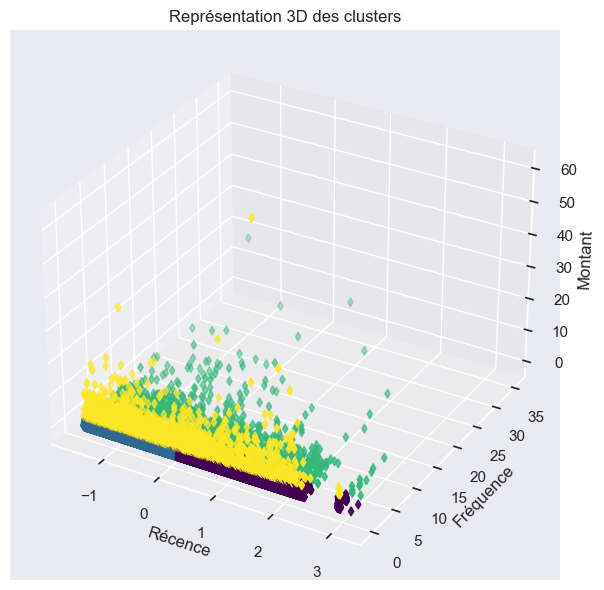

In [75]:
figure(model2, df_scaled_1)

In [76]:
model3 = KMeans(n_clusters=4,
                init='k-means++',
                n_init=10,
                max_iter=500,
                tol=0.0001,
                verbose=0,
                random_state=None,
                copy_x=True,
                algorithm='full')

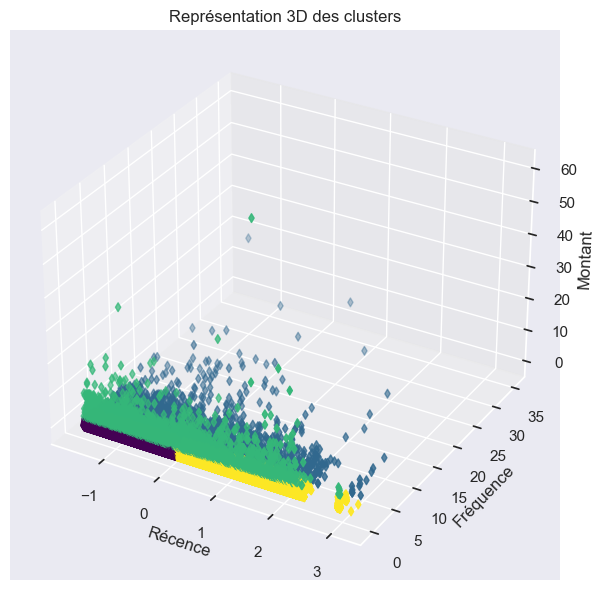

In [77]:
figure(model3, df_scaled_1)

In [78]:
model4 = KMeans(n_clusters=4,
                init='k-means++',
                n_init=10,
                max_iter=300,
                tol=0.0001,
                verbose=0,
                random_state=None,
                copy_x=True,
                algorithm='elkan')

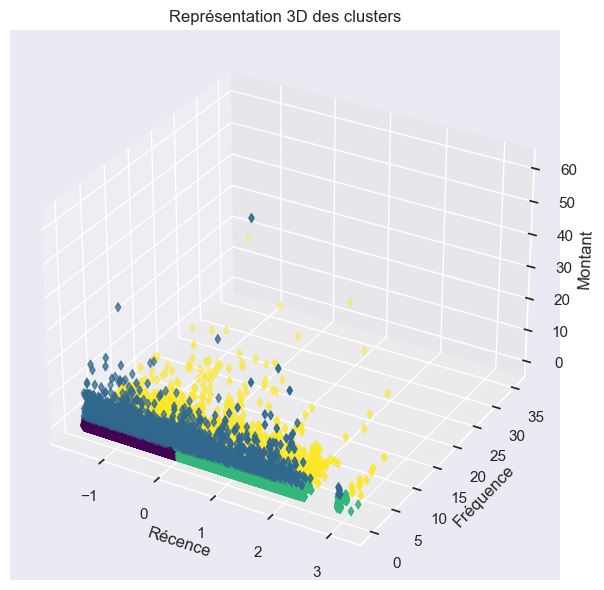

In [79]:
figure(model4, df_scaled_1)

In [80]:
model5 = KMeans(n_clusters=4,
                init='k-means++',
                n_init=10,
                max_iter=500,
                tol=0.0001,
                verbose=0,
                random_state=None,
                copy_x=True,
                algorithm='elkan')

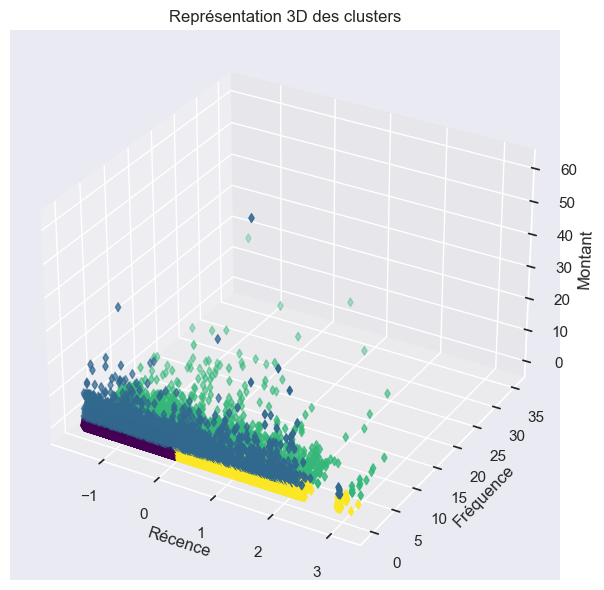

In [81]:
figure(model5, df_scaled_1)

In [82]:
# lorsque l'on modifie les hyperparamètres (method, n_init et max_iter), le clustering reste similaire

## Autres modèles de clustering

In [83]:
from sklearn.cluster import OPTICS
# doc https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html#sklearn.cluster.OPTICS

In [84]:
clustering1 = OPTICS(min_samples=100, max_eps=0.5).fit(df_scaled_1)

KeyboardInterrupt: 

In [128]:
from collections import Counter

print("Nombre de clients par Cluster :", Counter(clustering1.labels_))

NameError: name 'clustering1' is not defined

In [ ]:
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)  # Affichage en 3D
fig.add_axes(ax)
ax.scatter(df_scaled_1[:, 0],
           df_scaled_1[:, 1],
           df_scaled_1[:, 2],
           label='Courbe',
           marker='d',
           c=clustering.labels_,
           cmap='viridis')  # Tracé des points 3D
#ax.scatter(clustering.cluster_centers_[:,0], clustering.cluster_centers_[:,1], clustering.cluster_centers_[:,2], c='r')
plt.title("Représentation 3D des clusters")
ax.set_xlabel('Récence')
ax.set_ylabel('Fréquence')
ax.set_zlabel('Montant')
plt.show()

In [ ]:
# -1 = outliers / faire varier max_eps

In [ ]:
clustering2 = OPTICS(min_samples=100, max_eps=1).fit(df_scaled_1)

In [ ]:
print("Nombre de clients par Cluster :", Counter(clustering2.labels_))

In [ ]:
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)  # Affichage en 3D
fig.add_axes(ax)
ax.scatter(df_scaled_1[:, 0],
           df_scaled_1[:, 1],
           df_scaled_1[:, 2],
           label='Courbe',
           marker='d',
           c=clustering2.labels_,
           cmap='viridis')  # Tracé des points 3D
#ax.scatter(clustering.cluster_centers_[:,0], clustering.cluster_centers_[:,1], clustering.cluster_centers_[:,2], c='r')
plt.title("Représentation 3D des clusters")
ax.set_xlabel('Récence')
ax.set_ylabel('Fréquence')
ax.set_zlabel('Montant')
plt.show()

import scipy.cluster.hierarchy as shc
exemple d'utilisation : https://stackabuse.com/hierarchical-clustering-with-python-and-scikit-learn/

In [136]:
# Faire un tirage aléatoire sample
from sklearn.model_selection import train_test_split

In [158]:
grand_df, mini_df = train_test_split(df_scaled_1, test_size=0.1)

In [159]:
from sklearn.cluster import AgglomerativeClustering

In [160]:
agg_clustering = AgglomerativeClustering(n_clusters=4).fit(mini_df)

In [161]:
agg_clustering

AgglomerativeClustering(n_clusters=4)

In [162]:
print("Nombre de clients par Cluster :", Counter(agg_clustering.labels_))

Nombre de clients par Cluster : Counter({3: 5576, 2: 2342, 0: 1144, 1: 411})


In [176]:
mini_df = pd.DataFrame(mini_df, columns=['R', 'F', 'M'])

In [177]:
KMeans_model = KMeans(n_clusters=4, random_state=5).fit(df_scaled_1)

In [178]:
mini_df['kmeans_clusters'] = KMeans_model.predict(mini_df)

C:\Users\LN6428\Anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


In [179]:
mini_df['agg_clusters'] = agg_clustering.labels_

In [126]:
from scipy.cluster.hierarchy import dendrogram

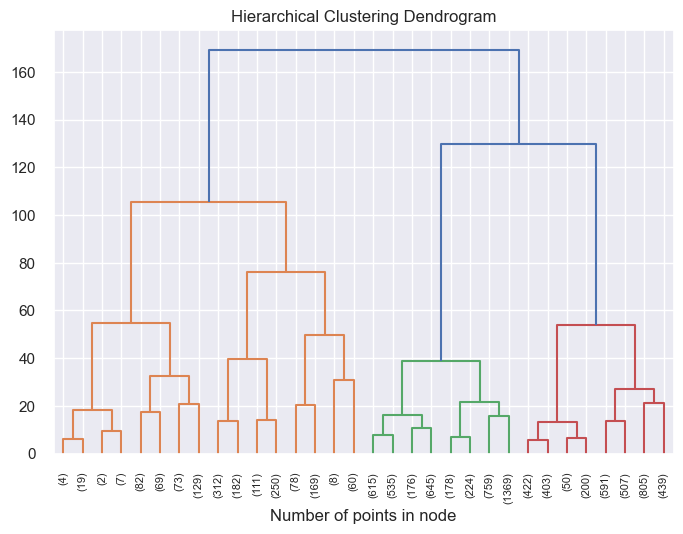

In [182]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


X = mini_df

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X)
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode="level", p=4)
plt.xlabel("Number of points in node")
plt.xticks(rotation='vertical')
plt.show()